# 📒 Notebook 08 — Integration Testing End-to-End Pipeline
## Spendly | Capstone AI Engineer

Notebook ini adalah **testing integrasi** tiga model secara sekuensial:

| Step | Model | Output |
|------|-------|--------|
| 1 | **NB07** MiniYOLO Receipt Detector | Bounding box → crop region |
| 2 | **NB05** CRNN OCR | Teks per region (date / store / total) |
| 3 | **NB03** Classifier | Kategori transaksi |

> ⚠️ Notebook ini **bukan deployment production** — murni untuk testing apakah ketiga model bekerja berurutan dari 1 foto struk hingga output JSON transaksi.

---

## Alur Pipeline

```
Foto struk masuk
      ↓
NB07 (MiniYOLO) → deteksi bounding box → crop region date/store/total
      ↓
NB05 (CRNN OCR) → baca teks dari tiap crop → "INDOMARET", "12/05/2025", "Rp105.800"
      ↓
NB03 (Classifier) → klasifikasi → kategori (F&B, Groceries, dst)
      ↓
Output JSON transaksi lengkap
```


## 1. Setup & Imports

In [1]:
# ── Imports Utama ─────────────────────────────────────────
import os
import re
import json
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from datetime import datetime
from tqdm import tqdm

import tensorflow as tf
from tensorflow import keras

print("TensorFlow version :", tf.__version__)
print("GPU available       :", tf.config.list_physical_devices('GPU'))

# ── Seed ──────────────────────────────────────────────────
import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("✅ Imports OK")


TensorFlow version : 2.10.0
GPU available       : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ Imports OK


In [2]:
import subprocess

gpus = tf.config.list_physical_devices('GPU')
print(f"Jumlah GPU terdeteksi TF: {len(gpus)}")
for gpu in gpus:
    print(f"  Device: {gpu.name}")

try:
    result = subprocess.run(
        ['nvidia-smi', '--query-gpu=index,name,memory.total,memory.free', '--format=csv,noheader'],
        capture_output=True, text=True
    )
    print("\nnvidia-smi GPU info:")
    for line in result.stdout.strip().split('\n'):
        print(f"  {line}")
except Exception as e:
    print(f"nvidia-smi tidak tersedia: {e}")

print(f"\nGPU aktif untuk TF: {tf.test.gpu_device_name()}")


Jumlah GPU terdeteksi TF: 1
  Device: /physical_device:GPU:0

nvidia-smi GPU info:
  0, NVIDIA GeForce RTX 3060 Ti, 8192 MiB, 5324 MiB

GPU aktif untuk TF: /device:GPU:0


In [3]:
import os
os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"

# Enable mixed precision for better GPU memory usage
from tensorflow.keras import mixed_precision
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)
print(f'Mixed precision policy: {policy.name}')

INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 3060 Ti, compute capability 8.6
Mixed precision policy: mixed_float16


## 2. Load Semua Model

In [4]:
# ── Path Model (sesuaikan sebelum run) ────────────────────
NB07_MODEL_PATH = "../models/receipt_detector_best.keras"   # sesuaikan
NB05_MODEL_PATH = "../models/ocr/ocr_fixed.keras"           # sesuaikan
NB03_MODEL_PATH = "../models/classifier/classifier.keras"         # sesuaikan

# ── Konfigurasi Global ─────────────────────────────────────
IMG_SIZE    = 416
CLASS_NAMES = ["date", "store", "total"]
NUM_CLASSES = 3

CATEGORIES = [
    "Beauty", "F&B", "Gas", "Groceries",
    "Health", "HouseHold", "Lifestyle", "Listrik", "Transport"
]

print("Path model:")
print(f"  NB07 : {NB07_MODEL_PATH}")
print(f"  NB05 : {NB05_MODEL_PATH}")
print(f"  NB03 : {NB03_MODEL_PATH}")


Path model:
  NB07 : ../models/receipt_detector_best.keras
  NB05 : ../models/ocr/ocr_fixed.keras
  NB03 : ../models/classifier/classifier.keras


In [5]:
# ── Load NB07 — MiniYOLO Receipt Detector ────────────────
# Custom objects yang dibutuhkan NB07
class L2NormalizationLayer(keras.layers.Layer):
    def __init__(self, n_channels, scale_init=20.0, **kwargs):
        super().__init__(**kwargs)
        self.n_channels = n_channels
        self.scale_init = scale_init

    def build(self, input_shape):
        self.gamma = self.add_weight(
            name="gamma",
            shape=(1, 1, 1, self.n_channels),   # ← harus 4D, bukan (n_channels,)
            initializer=keras.initializers.Constant(self.scale_init),
            trainable=True,
        )
        super().build(input_shape)

    def call(self, x):
        norm = tf.norm(x, axis=-1, keepdims=True) + 1e-7
        return self.gamma * (x / norm)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"n_channels": self.n_channels, "scale_init": self.scale_init})
        return cfg


class AnchorBoxLayer(keras.layers.Layer):
    def __init__(self, anchors, grid_h, grid_w, num_classes, **kwargs):
        super().__init__(**kwargs)
        self.anchors_list = anchors if isinstance(anchors, list) else anchors.tolist()
        self.grid_h       = grid_h
        self.grid_w       = grid_w
        self.num_classes  = num_classes
        self.num_anchors  = len(self.anchors_list)
    def build(self, input_shape):
        self._anchors_tf = tf.constant(self.anchors_list, dtype=tf.float32)
        super().build(input_shape)
    def call(self, raw):
        raw = tf.cast(raw, tf.float32)  # ← fix float16 mismatch
        batch = tf.shape(raw)[0]
        raw = tf.reshape(raw, [batch, self.grid_h, self.grid_w,
                               self.num_anchors, 5 + self.num_classes])
        grid_y = tf.range(self.grid_h, dtype=tf.float32)
        grid_x = tf.range(self.grid_w, dtype=tf.float32)
        gx, gy = tf.meshgrid(grid_x, grid_y)
        grid   = tf.stack([gx, gy], axis=-1)
        grid   = tf.reshape(grid, [1, self.grid_h, self.grid_w, 1, 2])
        xy  = (tf.sigmoid(raw[..., 1:3]) + grid)
        xy  = xy / tf.cast([self.grid_w, self.grid_h], tf.float32)
        anchors = tf.reshape(self._anchors_tf, [1, 1, 1, self.num_anchors, 2])
        wh  = tf.exp(tf.clip_by_value(raw[..., 3:5], -4.0, 4.0)) * anchors
        obj = tf.sigmoid(raw[..., 0:1])
        cls = tf.sigmoid(raw[..., 5:])
        return tf.concat([obj, xy, wh, cls], axis=-1)
    def get_config(self):
        cfg = super().get_config()
        cfg.update({"anchors": self.anchors_list, "grid_h": self.grid_h,
                    "grid_w": self.grid_w, "num_classes": self.num_classes})
        return cfg


class DetectionLoss(keras.losses.Loss):
    def __init__(self, lambda_coord=10.0, lambda_noobj=0.3,
                 lambda_cls=1.0, num_classes=3,
                 label_smoothing=0.1, class_weights=None, **kwargs):
        super().__init__(**kwargs)
        self.lambda_coord    = lambda_coord
        self.lambda_noobj    = lambda_noobj
        self.lambda_cls      = lambda_cls
        self.num_classes     = num_classes
        self.label_smoothing = label_smoothing
        self.class_weights   = class_weights or [1.5, 1.5, 6.0]

    @staticmethod
    def _ciou(box_true, box_pred):
        eps  = 1e-7
        tx1  = box_true[..., 0] - box_true[..., 2] / 2
        ty1  = box_true[..., 1] - box_true[..., 3] / 2
        tx2  = box_true[..., 0] + box_true[..., 2] / 2
        ty2  = box_true[..., 1] + box_true[..., 3] / 2
        px1  = box_pred[..., 0] - box_pred[..., 2] / 2
        py1  = box_pred[..., 1] - box_pred[..., 3] / 2
        px2  = box_pred[..., 0] + box_pred[..., 2] / 2
        py2  = box_pred[..., 1] + box_pred[..., 3] / 2

        inter_w = tf.maximum(tf.minimum(tx2, px2) - tf.maximum(tx1, px1), 0.0)
        inter_h = tf.maximum(tf.minimum(ty2, py2) - tf.maximum(ty1, py1), 0.0)
        inter   = inter_w * inter_h
        union   = box_true[..., 2]*box_true[..., 3] + box_pred[..., 2]*box_pred[..., 3] - inter + eps
        iou     = inter / union

        enc_x1 = tf.minimum(tx1, px1); enc_x2 = tf.maximum(tx2, px2)
        enc_y1 = tf.minimum(ty1, py1); enc_y2 = tf.maximum(ty2, py2)
        c2      = tf.square(enc_x2 - enc_x1) + tf.square(enc_y2 - enc_y1) + eps
        d2      = tf.square(box_true[..., 0] - box_pred[..., 0]) + tf.square(box_true[..., 1] - box_pred[..., 1])

        atan_t = tf.atan(box_true[..., 2] / (box_true[..., 3] + eps))
        atan_p = tf.atan(box_pred[..., 2] / (box_pred[..., 3] + eps))
        v      = (4.0 / (np.pi ** 2)) * tf.square(atan_t - atan_p)
        alpha  = tf.stop_gradient(v / (1.0 - iou + v + eps))

        return 1.0 - (iou - d2 / c2 - alpha * v)

    def call(self, y_true, y_pred):
        obj_mask   = y_true[..., 0:1]
        noobj_mask = 1.0 - obj_mask
        eps        = 1e-7

        obj_pred = y_pred[..., 0:1]
        obj_bce  = -(obj_mask * tf.math.log(obj_pred + eps) +
                     noobj_mask * tf.math.log(1.0 - obj_pred + eps))
        focal_w  = tf.pow(tf.abs(obj_mask - obj_pred), 2.0)
        obj_bce  = focal_w * obj_bce
        obj_loss = (tf.reduce_mean(obj_mask * obj_bce) +
                    self.lambda_noobj * tf.reduce_mean(noobj_mask * obj_bce))

        ciou_val   = self._ciou(y_true[..., 1:5], y_pred[..., 1:5])
        coord_loss = self.lambda_coord * tf.reduce_mean(obj_mask * tf.expand_dims(ciou_val, -1))

        cls_true   = y_true[..., 5:]
        cls_pred   = y_pred[..., 5:]
        smooth     = self.label_smoothing
        n          = tf.cast(self.num_classes, tf.float32)
        cls_smooth = cls_true * (1.0 - smooth) + smooth / n
        cls_bce    = -(cls_smooth * tf.math.log(cls_pred + eps) +
                       (1.0 - cls_smooth) * tf.math.log(1.0 - cls_pred + eps))
        cls_bce    = cls_bce * tf.constant([1.0, 1.0, 2.0], dtype=tf.float32)
        cls_loss   = self.lambda_cls * tf.reduce_mean(
                         obj_mask * tf.reduce_sum(cls_bce, axis=-1, keepdims=True))

        return obj_loss + coord_loss + cls_loss

    def get_config(self):
        cfg = super().get_config()
        cfg.update({
            "lambda_coord":    self.lambda_coord,
            "lambda_noobj":    self.lambda_noobj,
            "lambda_cls":      self.lambda_cls,
            "num_classes":     self.num_classes,
            "label_smoothing": self.label_smoothing,
            "class_weights": self.class_weights,
        })
        return cfg

class WarmupCosineDecay(keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, lr_init, lr_min, warmup_steps, total_steps):
        self.lr_init           = lr_init
        self.lr_min            = lr_min
        self._warmup_steps_int = int(warmup_steps)
        self._total_steps_int  = int(total_steps)
        self.warmup_steps      = tf.cast(warmup_steps, tf.float32)
        self.total_steps       = tf.cast(total_steps,  tf.float32)

    def __call__(self, step):
        step      = tf.cast(step, tf.float32)
        warmup_lr = self.lr_min + (self.lr_init - self.lr_min) * (
            step / self.warmup_steps
        )
        cosine_lr = self.lr_min + 0.5 * (self.lr_init - self.lr_min) * (
            1.0 + tf.cos(
                np.pi * (step - self.warmup_steps) /
                (self.total_steps - self.warmup_steps + 1e-7)
            )
        )
        return tf.where(step < self.warmup_steps, warmup_lr, cosine_lr)

    def get_config(self):
        return {
            "lr_init":      self.lr_init,
            "lr_min":       self.lr_min,
            "warmup_steps": self._warmup_steps_int,
            "total_steps":  self._total_steps_int,
        }

# --- lanjut seperti biasa ---
NB07_CUSTOM_OBJECTS = {
    "L2NormalizationLayer": L2NormalizationLayer,
    "AnchorBoxLayer":       AnchorBoxLayer,
    "DetectionLoss":        DetectionLoss,
    "WarmupCosineDecay":    WarmupCosineDecay,
}


try:
    nb07_model = keras.models.load_model(
        NB07_MODEL_PATH,
        custom_objects=NB07_CUSTOM_OBJECTS
    )
    print("✅ NB07 (MiniYOLO Detector) loaded:", NB07_MODEL_PATH)
    nb07_ok = True
except Exception as e:
    print(f"⚠️  NB07 gagal load: {e}")
    nb07_model = None
    nb07_ok    = False


✅ NB07 (MiniYOLO Detector) loaded: ../models/receipt_detector_best.keras


In [6]:
# ── Load NB05 — CRNN OCR ─────────────────────────────────
class CTCLayer(keras.layers.Layer):
    """Placeholder CTCLayer untuk load model NB05."""
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, inputs):
        return inputs

    def get_config(self):
        return super().get_config()


class FocalLoss(keras.losses.Loss):
    """Placeholder FocalLoss untuk load model NB03/NB05."""
    def __init__(self, gamma=2.0, alpha=0.25, class_weights=None, **kwargs):
        super().__init__(**kwargs)
        self.gamma = gamma
        self.alpha = alpha
        self.class_weights = class_weights

    def call(self, y_true, y_pred):
        bce   = tf.keras.backend.binary_crossentropy(y_true, y_pred)
        p_t   = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        alpha = y_true * self.alpha + (1 - y_true) * (1 - self.alpha)
        return alpha * tf.pow(1 - p_t, self.gamma) * bce

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"gamma": self.gamma, "alpha": self.alpha, "class_weights": self.class_weights})
        return cfg


NB05_CUSTOM_OBJECTS = {
    "CTCLayer":  CTCLayer,
    "FocalLoss": FocalLoss,
}

try:
    nb05_model = keras.models.load_model(
        NB05_MODEL_PATH,
        custom_objects=NB05_CUSTOM_OBJECTS
    )
    print("✅ NB05 (CRNN OCR) loaded:", NB05_MODEL_PATH)
    nb05_ok = True
except Exception as e:
    print(f"⚠️  NB05 gagal load: {e}")
    print("   Fallback ke regex akan digunakan untuk parsing teks.")
    nb05_model = None
    nb05_ok    = False


✅ NB05 (CRNN OCR) loaded: ../models/ocr/ocr_fixed.keras


In [7]:
import joblib
import sys, os, joblib

sys.path.insert(0, os.path.abspath("../src"))  # ← arahkan ke folder src

from custom_components import SEBlock, NLPPreprocessor
# ── Path tambahan NB03 ────────────────────────────────────
NB03_VECTORIZER_PATH       = "../models/classifier/tfidf_vectorizer.joblib"
NB03_NLP_PREPROCESSOR_PATH = "../models/classifier/nlp_preprocessor.joblib"

# ── Load NB03 — Classifier ───────────────────────────────
NB03_CUSTOM_OBJECTS = {
    "FocalLoss": FocalLoss,
    "SEBlock": SEBlock,  # sudah didefinisikan di block load NB05 di atas
}

try:
    nb03_model = keras.models.load_model(
        NB03_MODEL_PATH,
        custom_objects=NB03_CUSTOM_OBJECTS
    )
    print("✅ NB03 (Classifier) loaded:", NB03_MODEL_PATH)
    nb03_ok = True
except Exception as e:
    print(f"⚠️  NB03 gagal load: {e}")
    nb03_model = None
    nb03_ok    = False

# ── Load TF-IDF Vectorizer ────────────────────────────────
try:
    nb03_tfidf = joblib.load(NB03_VECTORIZER_PATH)
    print("✅ NB03 TF-IDF vectorizer loaded:", NB03_VECTORIZER_PATH)
except Exception as e:
    print(f"⚠️  TF-IDF vectorizer gagal load: {e}")
    nb03_tfidf = None

# ── Load NLP Preprocessor (Sastrawi) ─────────────────────
try:
    from custom_components import NLPPreprocessor   # ← import langsung
    nb03_nlp = NLPPreprocessor()
    print("✅ NB03 NLP Preprocessor loaded (instantiated from custom_components)")
except Exception as e:
    print(f"⚠️  NLP Preprocessor gagal load: {e}")
    nb03_nlp = None

# ── Update CATEGORIES (harus sama persis dengan NB03) ─────
# ⚠️ NB03 pakai "Transport" lowercase — jangan diganti
CATEGORIES = [
    "Beauty", "F&B", "Gas", "Groceries",
    "Health", "HouseHold", "Lifestyle", "Listrik", "Transport"
]

✅ NB03 (Classifier) loaded: ../models/classifier/classifier.keras
✅ NB03 TF-IDF vectorizer loaded: ../models/classifier/tfidf_vectorizer.joblib
✅ NB03 NLP Preprocessor loaded (instantiated from custom_components)


## 3. Fungsi Helper

In [8]:
# ── Helper NB07: compute_iou ──────────────────────────────
def compute_iou(box1, box2):
    """
    Hitung IoU antara dua box.
    Format: [cx, cy, w, h] normalized.
    """
    x1_min = box1[0] - box1[2]/2;  x1_max = box1[0] + box1[2]/2
    y1_min = box1[1] - box1[3]/2;  y1_max = box1[1] + box1[3]/2
    x2_min = box2[0] - box2[2]/2;  x2_max = box2[0] + box2[2]/2
    y2_min = box2[1] - box2[3]/2;  y2_max = box2[1] + box2[3]/2

    inter_w = max(0, min(x1_max, x2_max) - max(x1_min, x2_min))
    inter_h = max(0, min(y1_max, y2_max) - max(y1_min, y2_min))
    inter   = inter_w * inter_h

    area1 = box1[2] * box1[3]
    area2 = box2[2] * box2[3]
    union = area1 + area2 - inter + 1e-7

    return inter / union


print("✅ compute_iou — defined")


✅ compute_iou — defined


In [9]:
# ── Helper NB07: decode_predictions & decode_predictions_dual ─
def decode_predictions(pred_tensor, conf_thresh=0.20, iou_thresh=0.45):
    """
    Decode output satu head → list of detections.
    pred_tensor: [grid_h, grid_w, num_anchors, 5+nc]
    Return: list of [cx, cy, w, h, score, cls_id]
    """
    detections = []
    gh, gw, na = pred_tensor.shape[:3]

    for gy in range(gh):
        for gx in range(gw):
            for a in range(na):
                cell = pred_tensor[gy, gx, a]
                conf = float(cell[0])
                if conf < conf_thresh:
                    continue
                cx = float(np.clip(cell[1], 0.0, 1.0))
                cy = float(np.clip(cell[2], 0.0, 1.0))
                w  = float(np.clip(cell[3], 0.0, 1.0))
                h  = float(np.clip(cell[4], 0.0, 1.0))
                cls_probs = cell[5:]
                cls_id    = int(np.argmax(cls_probs))
                cls_conf  = float(cls_probs[cls_id])
                score     = conf * cls_conf
                if score >= conf_thresh:
                    detections.append([cx, cy, w, h, score, cls_id])

    if not detections:
        return []

    detections.sort(key=lambda x: -x[4])
    kept = []
    while detections:
        best = detections.pop(0)
        kept.append(best)
        detections = [
            d for d in detections
            if compute_iou(best[:4], d[:4]) < iou_thresh or d[5] != best[5]
        ]
    return kept


def decode_predictions_dual(pred26, pred52, conf_thresh=0.35, iou_thresh=0.45):
    """
    Merge deteksi dari kedua head (26x26 dan 52x52), lalu NMS gabungan.
    FIX: Setelah NMS, enforce TEPAT 1 deteksi per class (ambil score tertinggi).
    Return: list of [cx, cy, w, h, score, cls_id]
    """
    dets26   = decode_predictions(pred26, conf_thresh=conf_thresh, iou_thresh=iou_thresh)
    dets52   = decode_predictions(pred52, conf_thresh=conf_thresh, iou_thresh=iou_thresh)
    all_dets = dets26 + dets52

    if not all_dets:
        return []

    all_dets.sort(key=lambda x: -x[4])

    # NMS gabungan (cross-head)
    kept = []
    while all_dets:
        best = all_dets.pop(0)
        kept.append(best)
        all_dets = [
            d for d in all_dets
            if compute_iou(best[:4], d[:4]) < iou_thresh or d[5] != best[5]
        ]

    # ── FIX: Enforce max 1 deteksi per class ──────────────────────────
    # Setelah NMS masih bisa ada >1 box per class (dari head berbeda).
    # Ambil 1 box dengan score tertinggi per class.
    best_per_class = {}
    for det in kept:
        cls_id = det[5]
        if cls_id not in best_per_class or det[4] > best_per_class[cls_id][4]:
            best_per_class[cls_id] = det
    return list(best_per_class.values())


print("✅ decode_predictions      — defined")
print("✅ decode_predictions_dual — defined (dual-head 26x26 + 52x52, max-1-per-class)")


✅ decode_predictions      — defined
✅ decode_predictions_dual — defined (dual-head 26x26 + 52x52, max-1-per-class)


In [10]:
# ── Helper NB07: preprocess_receipt ──────────────────────
def preprocess_receipt(image_path, img_size=IMG_SIZE):
    """
    Load, resize, normalize gambar struk ke float32 [0,1].
    Return: (img_float32, img_rgb_uint8)
    """
    img = cv2.imread(str(image_path))
    if img is None:
        raise FileNotFoundError(f"Gambar tidak ditemukan: {image_path}")
    img_rgb   = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (img_size, img_size))
    img_float = img_resized.astype(np.float32) / 255.0
    return img_float, img_rgb


print("✅ preprocess_receipt — defined")


✅ preprocess_receipt — defined


In [11]:
# ── Helper NB07: detect_receipt_regions ──────────────────
def detect_receipt_regions(model, image_path,
                            conf_thresh=0.25, iou_thresh=0.45,
                            img_size=IMG_SIZE, pad_px=8):
    """
    Jalankan NB07 pada satu foto struk → deteksi bounding box.
    FIX: pad_px menambah margin sekitar crop agar teks di tepi tidak terpotong.

    Return:
        detections : dict {
            'date'           : list of {bbox, score, crop},
            'store'          : list of {bbox, score, crop},
            'total'          : list of {bbox, score, crop},
            'all_detections' : list of {class, bbox, score, crop}
        }
        img_rgb    : np.ndarray gambar asli (RGB, uint8)
    """
    img_float, img_rgb = preprocess_receipt(image_path, img_size)
    h_orig, w_orig     = img_rgb.shape[:2]

    img_t = tf.expand_dims(img_float, 0)
    out   = model(img_t, training=False)

    # Support single-head (tensor) dan dual-head (list/tuple)
    if isinstance(out, (list, tuple)):
        pred26 = out[0][0].numpy()
        pred52 = out[1][0].numpy()
        preds  = decode_predictions_dual(pred26, pred52,
                                         conf_thresh=conf_thresh,
                                         iou_thresh=iou_thresh)
    else:
        preds = decode_predictions(out[0].numpy(),
                                   conf_thresh=conf_thresh,
                                   iou_thresh=iou_thresh)

    detections = {"date": [], "store": [], "total": [], "all_detections": []}

    for cx, cy, w, h, score, cls_id in preds:
        cls_name = CLASS_NAMES[cls_id]

        # ── FIX: Hitung pixel coords + padding agar teks tidak terpotong ──
        x1 = int(np.clip((cx - w/2) * w_orig - pad_px, 0, w_orig - 1))
        y1 = int(np.clip((cy - h/2) * h_orig - pad_px, 0, h_orig - 1))
        x2 = int(np.clip((cx + w/2) * w_orig + pad_px, 0, w_orig))
        y2 = int(np.clip((cy + h/2) * h_orig + pad_px, 0, h_orig))

        crop = img_rgb[y1:y2, x1:x2]
        if crop.size == 0:
            continue

        det_entry = {
            "class": cls_name,
            "bbox":  [x1, y1, x2, y2],
            "score": round(float(score), 4),
            "crop":  crop,
        }
        detections[cls_name].append(det_entry)
        detections["all_detections"].append(det_entry)

    return detections, img_rgb


print("✅ detect_receipt_regions  — defined (with bbox padding)")


✅ detect_receipt_regions  — defined (with bbox padding)


In [12]:
# ── Helper NB07: visualize_detections ────────────────────
def visualize_detections(img_rgb, detections, save_path=None, show=True):
    """
    Gambar bounding box hasil deteksi NB07 di atas gambar asli.
    """
    COLORS = {
        "date":  (255,  80,  80),
        "store": (80,  220,  80),
        "total": (80,  150, 255),
    }

    vis = img_rgb.copy()
    for det in detections["all_detections"]:
        x1, y1, x2, y2 = det["bbox"]
        color = COLORS.get(det["class"], (200, 200, 200))
        cv2.rectangle(vis, (x1, y1), (x2, y2), color, 2)
        label = f"{det['class']} {det['score']:.2f}"
        cv2.putText(vis, label, (x1, max(y1 - 6, 10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, color, 2)

    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    ax.imshow(vis)
    ax.axis("off")
    ax.set_title("Deteksi Region Struk — NB07 MiniYOLO", fontsize=12)

    if save_path:
        plt.savefig(save_path, dpi=120, bbox_inches="tight")
        print(f"  💾 Visualisasi disimpan: {save_path}")
    if show:
        plt.show()
    plt.close()


print("✅ visualize_detections    — defined")


✅ visualize_detections    — defined


In [13]:
# ── Helper NB05: preprocess_crop_for_ocr ─────────────────
def preprocess_crop_for_ocr(crop_gray, target_w=400, target_h=50):
    """
    Preprocessing crop untuk CRNN OCR — disesuaikan dengan NB05 v5.

    NB05 v5 training pipeline:
      - Sintetis: PIL render (bg putih, teks gelap) -> noise -> resize -> /255
      - Real crop: cv2.imread grayscale -> resize LANCZOS -> /255
      - TIDAK ada adaptiveThreshold, TIDAK ada CLAHE kuat.

    Goal: bawa foto struk asli ke domain yg mirip training.
    Foto struk cenderung: background abu/coklat, teks gelap.
    Kita ingin: background terang, teks gelap, ukuran 400x50.
    """
    # Pastikan grayscale uint8
    if len(crop_gray.shape) == 3:
        crop_gray = cv2.cvtColor(crop_gray, cv2.COLOR_BGR2GRAY)
    if crop_gray.dtype != np.uint8:
        crop_gray = (crop_gray * 255).astype(np.uint8)

    # 1. CLAHE ringan — tingkatkan kontras lokal
    clahe = cv2.createCLAHE(clipLimit=1.5, tileGridSize=(4, 4))
    crop_gray = clahe.apply(crop_gray)

    # 2. Denoise ringan (sebelum resize)
    crop_gray = cv2.fastNlMeansDenoising(crop_gray, None, h=5,
                                          templateWindowSize=7,
                                          searchWindowSize=15)

    # 3. Resize ke target — pakai INTER_LANCZOS4 (sama dengan NB05 real crops)
    crop_gray = cv2.resize(crop_gray, (target_w, target_h),
                           interpolation=cv2.INTER_LANCZOS4)

    # 4. Linear histogram stretch: background -> putih, teks -> gelap
    #    Tujuan: bawa gambar ke domain sintetis NB05
    p_low  = float(np.percentile(crop_gray,  5))  # titik gelap
    p_high = float(np.percentile(crop_gray, 95))  # titik terang
    if p_high - p_low > 10:  # hanya kalau ada variasi
        crop_float = (crop_gray.astype(np.float32) - p_low) / (p_high - p_low)
        crop_float = np.clip(crop_float, 0.0, 1.0)
    else:
        crop_float = crop_gray.astype(np.float32) / 255.0

    return crop_float


# ── Charset: identik persis dengan NB05 v5 Cell 4 ──────────
# NB05 v5: CHARS = '0123456789ABCDE...xyz .,:-/()%'
# len=71, BLANK_IDX=72, NUM_CHARS=73
CHARS       = "0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz .,:-/()%"
IDX_TO_CHAR = {i+1: c for i, c in enumerate(CHARS)}
BLANK_IDX   = len(CHARS) + 1   # = 72
NUM_CHARS   = len(CHARS) + 2   # = 73

assert len(CHARS) == 71, f"ERROR: CHARS harus 71 karakter, dapat {len(CHARS)}"
assert BLANK_IDX == 72, f"ERROR: BLANK_IDX harus 72, dapat {BLANK_IDX}"
print(f"CHARS length : {len(CHARS)} karakter  (BLANK_IDX={BLANK_IDX}, NUM_CHARS={NUM_CHARS})")
print(f"CHARS        : '{CHARS}'")


def decode_ocr_prediction(pred_logits):
    """
    CTC greedy decode — identik dengan decode_prediction() di NB05 v5 cell 6.
    pred_logits: shape (T, num_chars)

    NB05 v5 decode:
      1. argmax per timestep
      2. collapse repeats
      3. buang BLANK_IDX dan idx yang tidak ada di IDX_TO_CHAR
    """
    pred_ids = np.argmax(pred_logits, axis=-1)  # (T,)
    # Collapse repeats
    collapsed = []
    prev = None
    for idx in pred_ids:
        if idx != prev:
            collapsed.append(idx)
        prev = idx
    # Remove blank dan idx tidak valid
    chars = [IDX_TO_CHAR[i] for i in collapsed
             if i != BLANK_IDX and i in IDX_TO_CHAR]
    return ''.join(chars)


print("[OK] preprocess_crop_for_ocr — domain-matched dengan NB05 v5 training")
print("[OK] decode_ocr_prediction   — identik dengan NB05 v5 decode_prediction")


CHARS length : 71 karakter  (BLANK_IDX=72, NUM_CHARS=73)
CHARS        : '0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz .,:-/()%'
[OK] preprocess_crop_for_ocr — domain-matched dengan NB05 v5 training
[OK] decode_ocr_prediction   — identik dengan NB05 v5 decode_prediction


Menggunakan: ../data/Beauty/test/images\guardian10_png.rf.3ef684fec3bc3393d8a1d5c232a344e4.jpg
Deteksi: 3 region


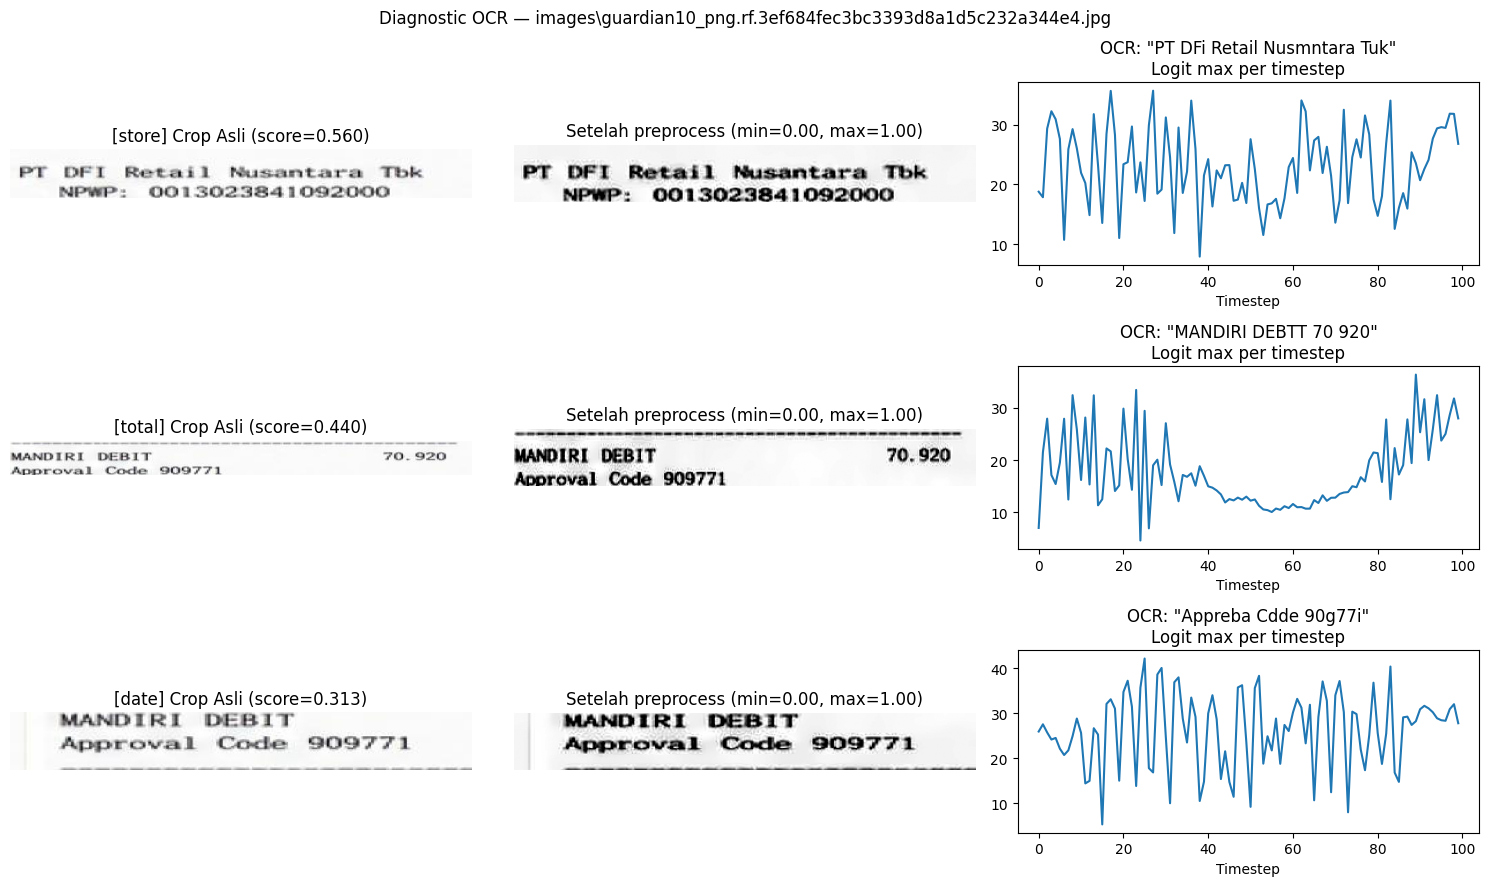

[OK] Diagnostic saved: outputs/diag_ocr_crop.png


In [14]:
# ── DIAGNOSTIC: Visualisasi Crop OCR ──────────────────────
# Jalankan cell ini untuk debug: lihat crop SEBELUM dan SESUDAH preprocess
# dan lihat apa yang diprediksi OCR secara visual.
import glob, matplotlib.pyplot as plt

# Ambil 1 gambar dari setiap kategori yang ada
_diag_paths = []
for cat in ['Beauty', 'F&B', 'Groceries', 'Listrik', 'HouseHold']:
    _found = glob.glob(f'../data/{cat}/test/images/*.jpg')
    if _found:
        _diag_paths.append(_found[0])

if not _diag_paths:
    print('Tidak ada gambar test ditemukan.')
else:
    _diag_img = _diag_paths[0]  # pakai 1 gambar saja
    print(f'Menggunakan: {_diag_img}')

    if nb07_model is not None:
        _dets, _img_rgb = detect_receipt_regions(
            nb07_model, _diag_img, conf_thresh=0.25, iou_thresh=0.45
        )
        print(f'Deteksi: {len(_dets["all_detections"])} region')

        n_det = len(_dets['all_detections'])
        if n_det == 0:
            print('Tidak ada region terdeteksi. Coba turunkan conf_thresh.')
        else:
            fig, axes = plt.subplots(n_det, 3, figsize=(15, n_det * 3))
            if n_det == 1:
                axes = [axes]

            for row_i, det in enumerate(_dets['all_detections']):
                cls_name = det['class']
                crop_rgb = det['crop']
                crop_g   = cv2.cvtColor(crop_rgb, cv2.COLOR_RGB2GRAY)

                # Col 0: crop asli (RGB)
                axes[row_i][0].imshow(crop_rgb)
                axes[row_i][0].set_title(f'[{cls_name}] Crop Asli (score={det["score"]:.3f})')
                axes[row_i][0].axis('off')

                # Col 1: crop setelah preprocess
                proc = preprocess_crop_for_ocr(crop_g)
                axes[row_i][1].imshow(proc, cmap='gray', vmin=0, vmax=1)
                axes[row_i][1].set_title(f'Setelah preprocess (min={proc.min():.2f}, max={proc.max():.2f})')
                axes[row_i][1].axis('off')

                # Col 2: OCR prediction
                if nb05_model is not None:
                    _inp = tf.expand_dims(tf.expand_dims(proc, 0), -1)
                    _out = nb05_model(_inp, training=False)
                    if isinstance(_out, (list, tuple)):
                        _out = _out[0]
                    _logits = _out[0].numpy()  # (T, num_chars)
                    _conf_per_ts = np.max(_logits, axis=-1)  # maks logit per timestep
                    _pred_text = decode_ocr_prediction(_logits)
                    _top_idx = np.argmax(_logits, axis=-1)
                    axes[row_i][2].plot(_conf_per_ts)
                    axes[row_i][2].set_title(f'OCR: "{_pred_text}"\nLogit max per timestep')
                    axes[row_i][2].set_xlabel('Timestep')
                else:
                    axes[row_i][2].text(0.5, 0.5, 'nb05_model=None', ha='center', va='center')
                    axes[row_i][2].axis('off')

        plt.suptitle(f'Diagnostic OCR — {_diag_img.split("/")[-1]}', fontsize=12)
        plt.tight_layout()
        plt.savefig('../outputs/diag_ocr_crop.png', dpi=120, bbox_inches='tight')
        plt.show()
        print('[OK] Diagnostic saved: outputs/diag_ocr_crop.png')
    else:
        print('nb07_model tidak tersedia — skip diagnostic.')


In [15]:
# ── Helper Regex Fallback (jika NB05 tidak tersedia) ──────
def parse_text_regex(text):
    """
    Ekstrak tanggal dan total dari teks raw menggunakan regex.
    Digunakan sebagai fallback jika CRNN tidak tersedia.
    """
    # Pola tanggal: DD/MM/YYYY, DD-MM-YYYY, YYYY-MM-DD
    date_pattern = r'(\d{2}[/\-]\d{2}[/\-]\d{2,4}|\d{4}[/\-]\d{2}[/\-]\d{2})'
    # Pola total: Rp + angka
    total_pattern = r'(?:Rp\.?\s*|IDR\s*)[\d.,]+'

    date_match  = re.search(date_pattern, text)
    total_match = re.search(total_pattern, text, re.IGNORECASE)

    return {
        "date":  date_match.group(0)  if date_match  else None,
        "total": total_match.group(0) if total_match else None,
    }


print("✅ parse_text_regex — defined (regex fallback)")


✅ parse_text_regex — defined (regex fallback)


In [16]:
# ── Helper NB03: preprocess_text_nb03 ────────────────────
def preprocess_text_nb03(text):
    """
    Teks OCR gabungan → TF-IDF vector untuk input branch text NB03.
    Return shape: (1, n_features), dtype float32
    """
    if nb03_tfidf is None:
        return np.zeros((1, 5000), dtype=np.float32)

    if nb03_nlp is not None:
        text_clean = nb03_nlp.preprocess(text)
    else:
        import re
        text_clean = text.lower()
        text_clean = re.sub(r'[^a-z0-9\s]', ' ', text_clean)
        text_clean = re.sub(r'\d+', 'NUM', text_clean)
        text_clean = re.sub(r'\s+', ' ', text_clean).strip()

    return nb03_tfidf.transform([text_clean]).toarray().astype(np.float32)

print("✅ preprocess_text_nb03    — defined")


# ── Helper NB03: preprocess_full_image_nb03 ──────────────
def preprocess_full_image_nb03(image_path, img_size=224):
    """
    Load foto struk PENUH → input branch image NB03.
    NB03 butuh foto penuh, bukan crop region.
    Return shape: (1, 224, 224, 3), dtype float32
    """
    img = cv2.imread(str(image_path))
    if img is None:
        return np.zeros((1, img_size, img_size, 3), dtype=np.float32)
    img_rgb    = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (img_size, img_size))
    img_float  = img_resized.astype(np.float32) / 255.0
    return np.expand_dims(img_float, axis=0)

print("✅ preprocess_full_image_nb03 — defined")

✅ preprocess_text_nb03    — defined
✅ preprocess_full_image_nb03 — defined


## 4. Fungsi Utama: spendly_pipeline()

In [17]:
# ── spendly_pipeline() — Pipeline Integrasi End-to-End ────
def spendly_pipeline(image_path,
                     conf_thresh=0.25,
                     iou_thresh=0.45,
                     visualize=True,
                     save_vis=True,
                     verbose=True):
    """
    Pipeline utama Spendly: foto struk → JSON transaksi.

    Alur:
      1. NB07 → detect bounding box → crop region date/store/total
      2. NB05 → OCR teks per crop (fallback: regex)
      3. NB03 → klasifikasi kategori (fallback: 'unknown')

    Parameter:
        image_path : str | Path — path foto struk
        conf_thresh: float      — confidence threshold NB07
        iou_thresh : float      — IoU threshold NMS NB07
        visualize  : bool       — tampilkan visualisasi deteksi
        save_vis   : bool       — simpan gambar visualisasi
        verbose    : bool       — print log tiap tahap

    Return:
        dict {
            "image_path"      : str,
            "parsed"          : {"store", "date", "total"},
            "kategori"        : str,
            "confidence"      : float,
            "ocr_method"      : str,
            "detector_method" : str,
            "n_regions"       : int,
            "timestamp"       : str,
        }
    """
    def vprint(*args, **kwargs):
        if verbose:
            print(*args, **kwargs)

    vprint(f"\n{'='*60}")
    vprint(f"  📷 Input : {os.path.basename(str(image_path))}")
    vprint(f"{'='*60}")

    result = {
        "image_path":      str(image_path),
        "parsed":          {"store": None, "date": None, "total": None},
        "kategori":        "unknown",
        "confidence":      0.0,
        "ocr_method":      "none",
        "detector_method": "miniyolo",
        "n_regions":       0,
        "timestamp":       datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    }

    # ── STEP 1: NB07 — Deteksi Region ─────────────────────
    vprint("\n  [1/3] 🔍 NB07 — Deteksi region struk...")
    if nb07_model is None:
        vprint("        ⚠️  NB07 tidak tersedia — pipeline dihentikan.")
        return result

    try:
        detections, img_rgb = detect_receipt_regions(
            nb07_model, image_path,
            conf_thresh=conf_thresh, iou_thresh=iou_thresh
        )
        n_det = len(detections["all_detections"])
        result["n_regions"] = n_det
        vprint(f"        Ditemukan {n_det} region:")
        for det in detections["all_detections"]:
            vprint(f"        → {det['class']:8s} (score={det['score']:.3f})")

        if visualize:
            save_path = f"detection_{Path(image_path).stem}.png" if save_vis else None
            visualize_detections(img_rgb, detections, save_path=save_path, show=True)

    except Exception as e:
        vprint(f"        ❌ Error saat deteksi: {e}")
        return result

    # ── STEP 2: NB05 — OCR Teks Per Region ────────────────
    vprint("\n  [2/3] 📝 NB05 — OCR teks per region...")
    parsed = {"store": None, "date": None, "total": None}

    for cls_name in ["store", "date", "total"]:
        if not detections[cls_name]:
            vprint(f"        {cls_name:8s}: ❌ tidak terdeteksi")
            continue

        best_det  = max(detections[cls_name], key=lambda x: x["score"])
        crop      = best_det["crop"]
        crop_gray = cv2.cvtColor(crop, cv2.COLOR_RGB2GRAY)

        if nb05_model is not None:
            try:
                crop_proc = preprocess_crop_for_ocr(crop_gray)
                crop_t    = tf.expand_dims(tf.expand_dims(crop_proc, 0), -1)
                ocr_pred  = nb05_model(crop_t, training=False)
                # Model CRNN bisa return tuple (pred, input_length) — ambil pred saja
                if isinstance(ocr_pred, (list, tuple)):
                    ocr_pred = ocr_pred[0]
                ocr_text = decode_ocr_prediction(ocr_pred[0].numpy())
                parsed[cls_name] = ocr_text.strip() if ocr_text.strip() else None
                vprint(f"        {cls_name:8s}: '{parsed[cls_name]}'  [CRNN]")
                result["ocr_method"] = "crnn"
            except Exception as e:
                vprint(f"        {cls_name:8s}: ⚠️  CRNN error ({e}) — coba regex")
                parsed[cls_name] = None
        else:
            vprint(f"        {cls_name:8s}: NB05 tidak tersedia — fallback regex")

    # Regex fallback untuk field yang kosong
    if None in (parsed["date"], parsed["total"]) and nb05_model is None:
        for cls_name in ["date", "total"]:
            if parsed[cls_name] is None and detections[cls_name]:
                # Tidak ada teks murni dari crop tanpa OCR model → tandai saja
                parsed[cls_name] = f"detected(score={detections[cls_name][0]['score']:.2f})"
        if result["ocr_method"] == "none":
            result["ocr_method"] = "regex_fallback"

    result["parsed"] = parsed

    # ── STEP 3: NB03 — Klasifikasi Kategori ───────────────
    vprint("\n  [3/3] 🏷️  NB03 — Klasifikasi kategori...")
    if nb03_model is not None:
        try:
            # -- TEXT INPUT: gabung teks OCR hasil NB05 --
            combined_text = " ".join(filter(None, [
                parsed.get("store", ""),
                parsed.get("date",  ""),
                parsed.get("total", ""),
            ]))
            text_input = preprocess_text_nb03(combined_text)
            # shape: (1, n_tfidf_features)

            # -- IMAGE INPUT: foto struk penuh, bukan crop --
            img_input = preprocess_full_image_nb03(image_path)
            # shape: (1, 224, 224, 3)

            # -- INFERENCE: dual branch [text, image] --
            cls_pred = nb03_model([text_input, img_input], training=False)
            if isinstance(cls_pred, (list, tuple)):
                cls_pred = cls_pred[0]

            cls_probs  = cls_pred[0].numpy()
            cls_idx    = int(np.argmax(cls_probs))
            confidence = float(np.max(cls_probs))
            kategori   = CATEGORIES[cls_idx] if cls_idx < len(CATEGORIES) else "unknown"

            result["kategori"]   = kategori
            result["confidence"] = round(confidence, 4)
            vprint(f"        Teks input : '{combined_text[:60]}'")
            vprint(f"        Kategori   : {kategori}  (conf={confidence:.3f})")

        except Exception as e:
            vprint(f"        ⚠️  NB03 error: {e} — fallback ke 'unknown'")
    else:
        vprint("        ⚠️  NB03 tidak tersedia — kategori: 'unknown'")

    # ── OUTPUT RINGKASAN ───────────────────────────────────
    vprint(f"\n  {'─'*55}")
    vprint(f"  📋 Hasil:")
    vprint(f"     Store    : {result['parsed']['store']}")
    vprint(f"     Date     : {result['parsed']['date']}")
    vprint(f"     Total    : {result['parsed']['total']}")
    vprint(f"     Kategori : {result['kategori']}  (conf={result['confidence']:.3f})")
    vprint(f"     OCR      : {result['ocr_method']}")
    vprint(f"     Regions  : {result['n_regions']} terdeteksi")
    vprint(f"  {'─'*55}")

    return result


print("✅ spendly_pipeline() — defined")
print("   Input : path foto struk")
print("   Output: dict JSON transaksi {store, date, total, kategori, confidence, ...}")


✅ spendly_pipeline() — defined
   Input : path foto struk
   Output: dict JSON transaksi {store, date, total, kategori, confidence, ...}


## 5. Testing Single Image

Ganti `TEST_IMAGE_PATH` dengan path foto struk yang ingin di-test.


✅ Ditemukan 9 kategori dengan gambar test


  🏷️  Kategori: Beauty

  📷 Input : guardian10_png.rf.3ef684fec3bc3393d8a1d5c232a344e4.jpg

  [1/3] 🔍 NB07 — Deteksi region struk...
        Ditemukan 2 region:
        → store    (score=0.560)
        → total    (score=0.440)


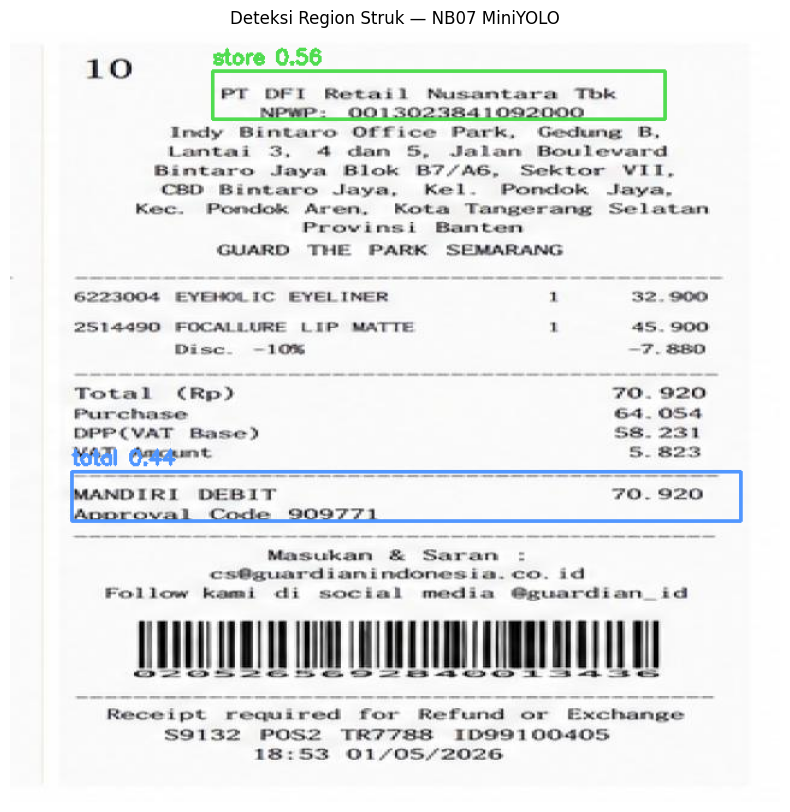


  [2/3] 📝 NB05 — OCR teks per region...
        store   : 'PT DFi Retail Nusmntara Tuk'  [CRNN]
        date    : ❌ tidak terdeteksi
        total   : 'MANDIRI DEBTT 70 920'  [CRNN]

  [3/3] 🏷️  NB03 — Klasifikasi kategori...
        Teks input : 'PT DFi Retail Nusmntara Tuk MANDIRI DEBTT 70 920'
        Kategori   : Beauty  (conf=0.911)

  ───────────────────────────────────────────────────────
  📋 Hasil:
     Store    : PT DFi Retail Nusmntara Tuk
     Date     : None
     Total    : MANDIRI DEBTT 70 920
     Kategori : Beauty  (conf=0.911)
     OCR      : crnn
     Regions  : 2 terdeteksi
  ───────────────────────────────────────────────────────

  🏷️  Kategori: F&B

  📷 Input : bk6_png.rf.e34da0ca4e159ee4a8758c7d05821494.jpg

  [1/3] 🔍 NB07 — Deteksi region struk...
        Ditemukan 3 region:
        → store    (score=0.586)
        → total    (score=0.443)
        → date     (score=0.375)


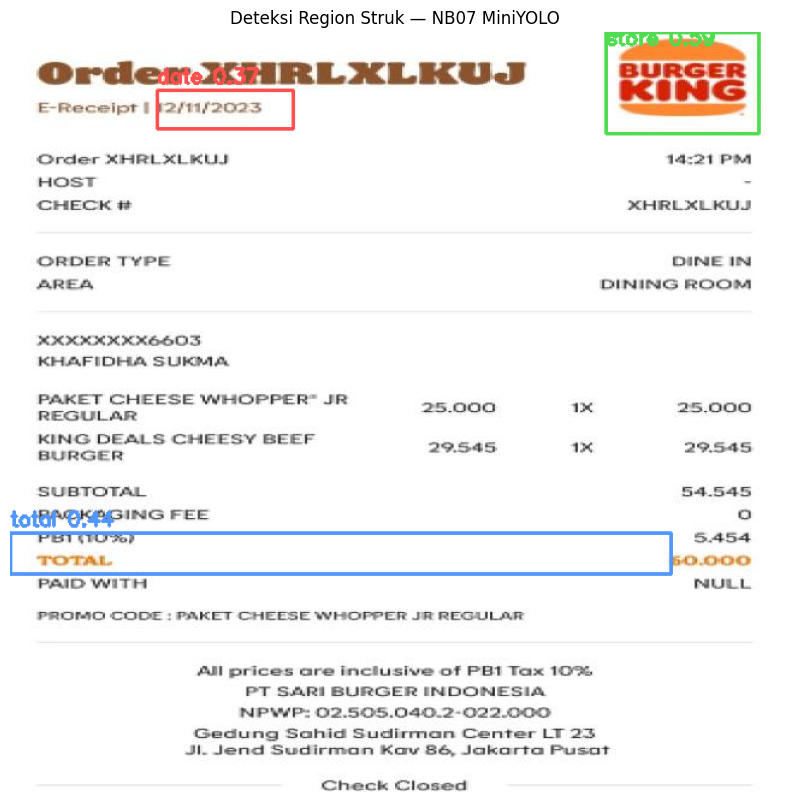


  [2/3] 📝 NB05 — OCR teks per region...
        store   : 'e'  [CRNN]
        date    : '2riir2or'  [CRNN]
        total   : 'Roii'  [CRNN]

  [3/3] 🏷️  NB03 — Klasifikasi kategori...
        Teks input : 'e 2riir2or Roii'
        Kategori   : Beauty  (conf=0.391)

  ───────────────────────────────────────────────────────
  📋 Hasil:
     Store    : e
     Date     : 2riir2or
     Total    : Roii
     Kategori : Beauty  (conf=0.391)
     OCR      : crnn
     Regions  : 3 terdeteksi
  ───────────────────────────────────────────────────────

  🏷️  Kategori: Gas

  📷 Input : bensin-affan1_jpeg.rf.59aa403b8196f7627ca9d7afcfb54dbb.jpg

  [1/3] 🔍 NB07 — Deteksi region struk...
        Ditemukan 2 region:
        → store    (score=0.491)
        → total    (score=0.368)


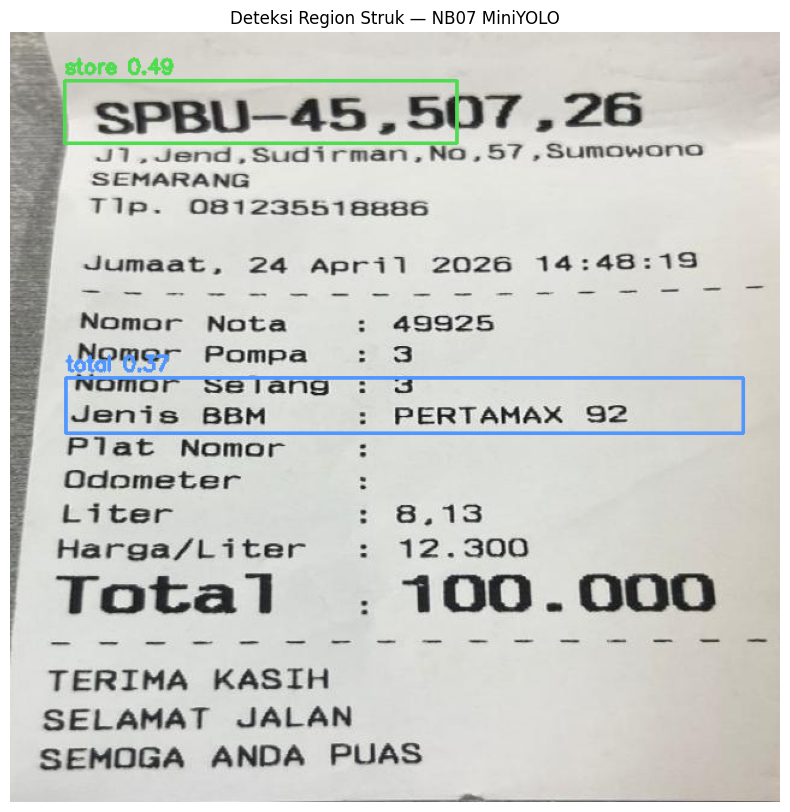


  [2/3] 📝 NB05 — OCR teks per region...
        store   : 'sppua5 50'  [CRNN]
        date    : ❌ tidak terdeteksi
        total   : 'eNgs eung penruy gZ'  [CRNN]

  [3/3] 🏷️  NB03 — Klasifikasi kategori...
        Teks input : 'sppua5 50 eNgs eung penruy gZ'
        Kategori   : Gas  (conf=0.317)

  ───────────────────────────────────────────────────────
  📋 Hasil:
     Store    : sppua5 50
     Date     : None
     Total    : eNgs eung penruy gZ
     Kategori : Gas  (conf=0.317)
     OCR      : crnn
     Regions  : 2 terdeteksi
  ───────────────────────────────────────────────────────

  🏷️  Kategori: Groceries

  📷 Input : receipt-067_png_jpg.rf.930186f0b80cca504c3de8ce3f66565d.jpg

  [1/3] 🔍 NB07 — Deteksi region struk...
        Ditemukan 3 region:
        → total    (score=0.728)
        → store    (score=0.593)
        → date     (score=0.461)


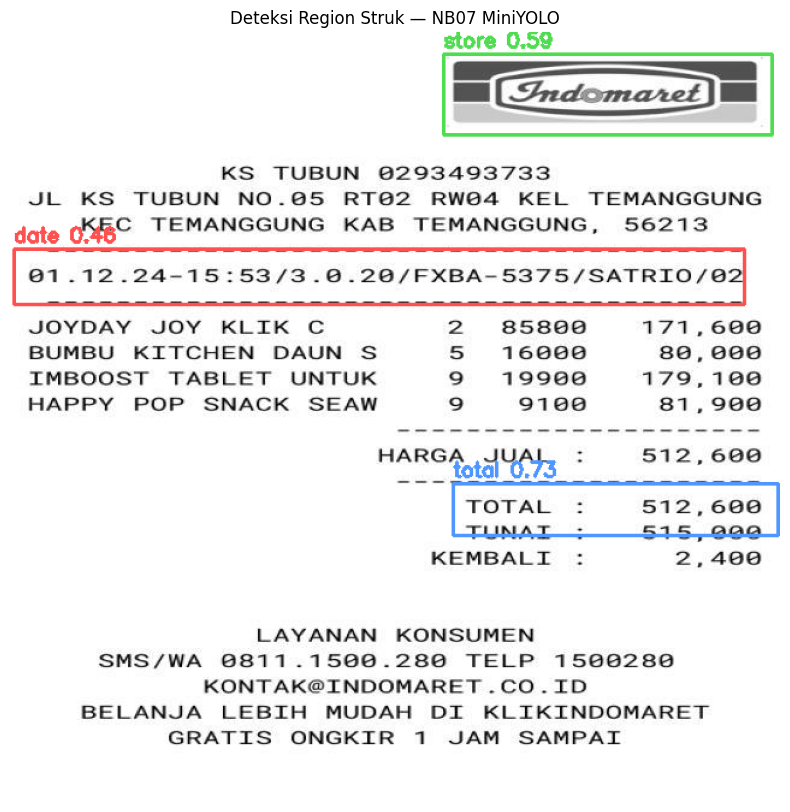


  [2/3] 📝 NB05 — OCR teks per region...
        store   : 'ECsr42G'  [CRNN]
        date    : '01 12 24-15:53/3 0 20/FB4-5375/SATRI0/02'  [CRNN]
        total   : 'TOTAL 512 600'  [CRNN]

  [3/3] 🏷️  NB03 — Klasifikasi kategori...
        Teks input : 'ECsr42G 01 12 24-15:53/3 0 20/FB4-5375/SATRI0/02 TOTAL 512 6'
        Kategori   : Groceries  (conf=0.467)

  ───────────────────────────────────────────────────────
  📋 Hasil:
     Store    : ECsr42G
     Date     : 01 12 24-15:53/3 0 20/FB4-5375/SATRI0/02
     Total    : TOTAL 512 600
     Kategori : Groceries  (conf=0.467)
     OCR      : crnn
     Regions  : 3 terdeteksi
  ───────────────────────────────────────────────────────

  🏷️  Kategori: Health

  📷 Input : 1dental11_png.rf.46847a727f668de66dd62216c6968d7a.jpg

  [1/3] 🔍 NB07 — Deteksi region struk...
        Ditemukan 3 region:
        → total    (score=0.743)
        → date     (score=0.598)
        → store    (score=0.570)


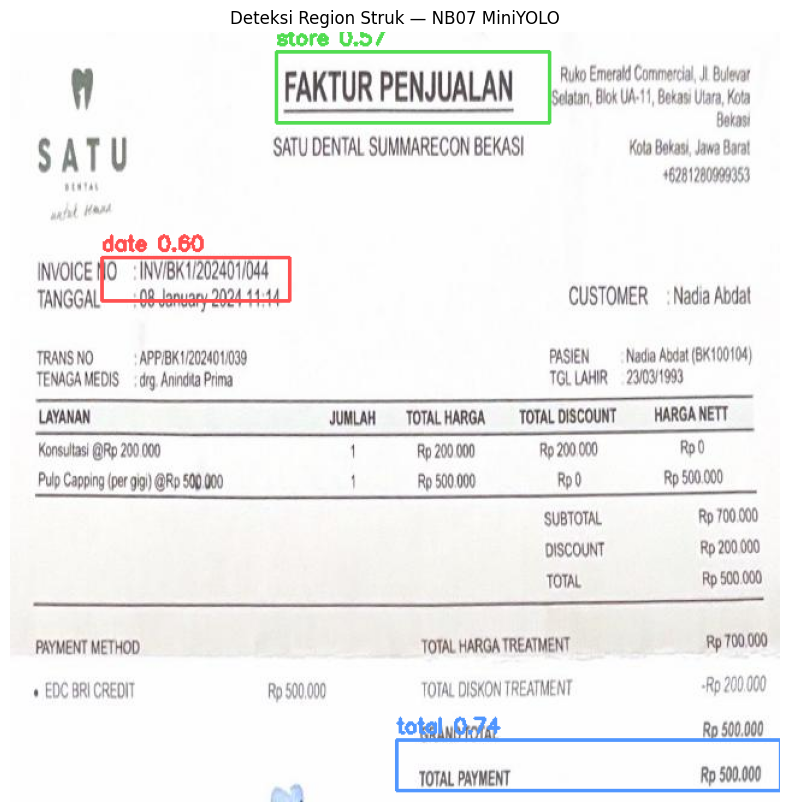


  [2/3] 📝 NB05 — OCR teks per region...
        store   : 'FAKTUR PENJUALAN'  [CRNN]
        date    : 'VO INVBK1/202401/044'  [CRNN]
        total   : 'JAmIP R ,,00'  [CRNN]

  [3/3] 🏷️  NB03 — Klasifikasi kategori...
        Teks input : 'FAKTUR PENJUALAN VO INVBK1/202401/044 JAmIP R ,,00'
        Kategori   : Lifestyle  (conf=0.324)

  ───────────────────────────────────────────────────────
  📋 Hasil:
     Store    : FAKTUR PENJUALAN
     Date     : VO INVBK1/202401/044
     Total    : JAmIP R ,,00
     Kategori : Lifestyle  (conf=0.324)
     OCR      : crnn
     Regions  : 3 terdeteksi
  ───────────────────────────────────────────────────────

  🏷️  Kategori: HouseHold

  📷 Input : azko20_png.rf.84f58140bd6604d26f6d9f62a114b01e.jpg

  [1/3] 🔍 NB07 — Deteksi region struk...
        Ditemukan 3 region:
        → date     (score=0.599)
        → total    (score=0.555)
        → store    (score=0.510)


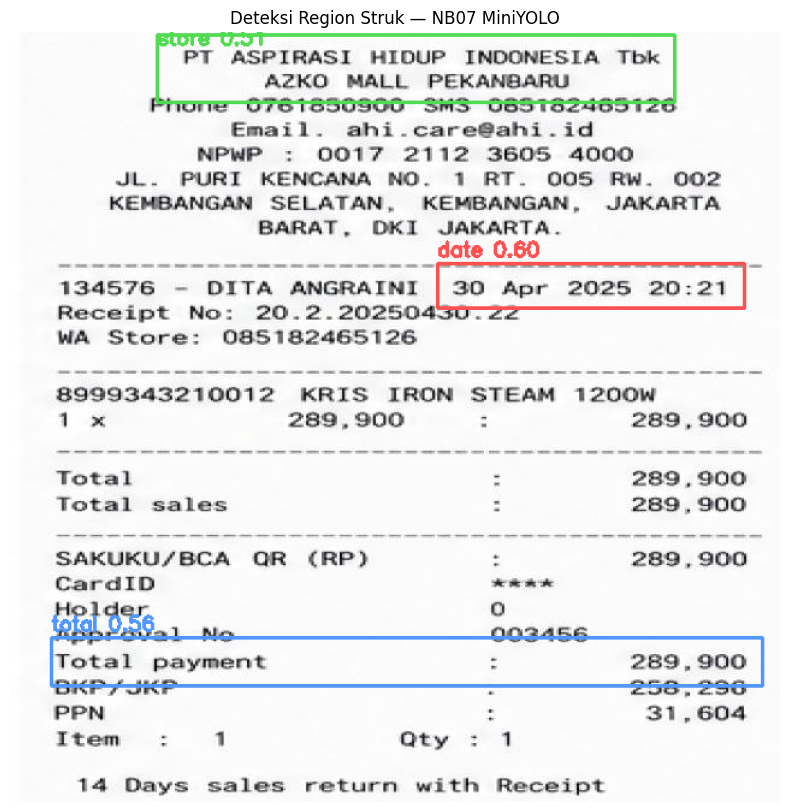


  [2/3] 📝 NB05 — OCR teks per region...
        store   : 'PT ASRIASIIIDUENDONESA TBK'  [CRNN]
        date    : '30 Apr 2025 20.21'  [CRNN]
        total   : 'Total Payment 269 000'  [CRNN]

  [3/3] 🏷️  NB03 — Klasifikasi kategori...
        Teks input : 'PT ASRIASIIIDUENDONESA TBK 30 Apr 2025 20.21 Total Payment 2'
        Kategori   : HouseHold  (conf=0.687)

  ───────────────────────────────────────────────────────
  📋 Hasil:
     Store    : PT ASRIASIIIDUENDONESA TBK
     Date     : 30 Apr 2025 20.21
     Total    : Total Payment 269 000
     Kategori : HouseHold  (conf=0.687)
     OCR      : crnn
     Regions  : 3 terdeteksi
  ───────────────────────────────────────────────────────

  🏷️  Kategori: Lifestyle

  📷 Input : Screenshot-2026-05-07-000222_png.rf.697ca58a545f786a9921bbbec102a431.jpg

  [1/3] 🔍 NB07 — Deteksi region struk...
        Ditemukan 2 region:
        → store    (score=0.599)
        → date     (score=0.395)


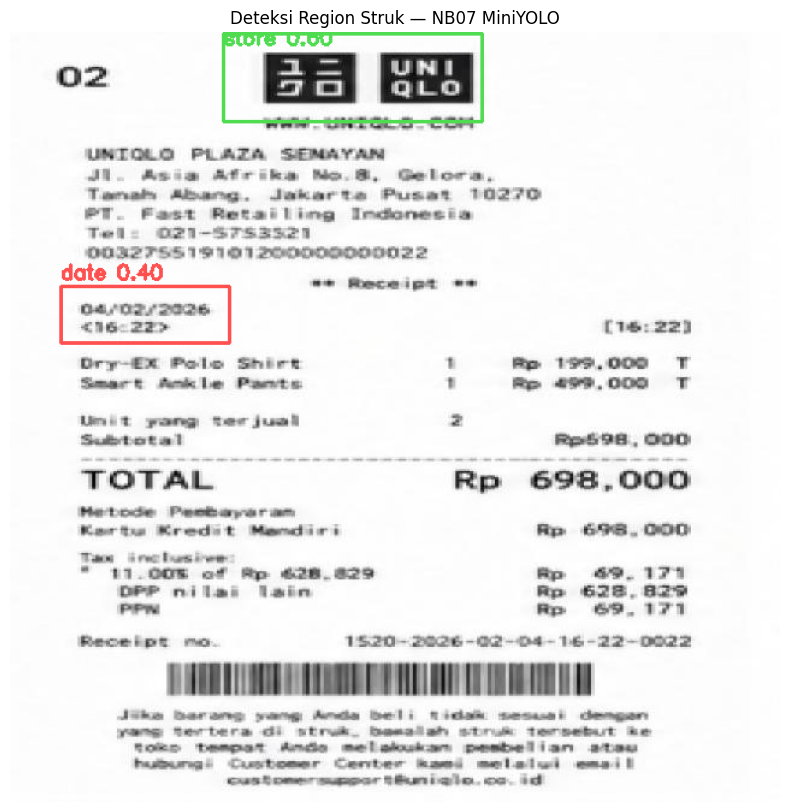


  [2/3] 📝 NB05 — OCR teks per region...
        store   : 'IEE EE1'  [CRNN]
        date    : 'SDs'  [CRNN]
        total   : ❌ tidak terdeteksi

  [3/3] 🏷️  NB03 — Klasifikasi kategori...
        Teks input : 'IEE EE1 SDs'
        Kategori   : Lifestyle  (conf=0.614)

  ───────────────────────────────────────────────────────
  📋 Hasil:
     Store    : IEE EE1
     Date     : SDs
     Total    : None
     Kategori : Lifestyle  (conf=0.614)
     OCR      : crnn
     Regions  : 2 terdeteksi
  ───────────────────────────────────────────────────────

  🏷️  Kategori: Listrik

  📷 Input : IMG-20260503-WA0061_jpg.rf.6500653f9bc657c9e4c8497c641a66eb.jpg

  [1/3] 🔍 NB07 — Deteksi region struk...
        Ditemukan 2 region:
        → total    (score=0.379)
        → store    (score=0.361)


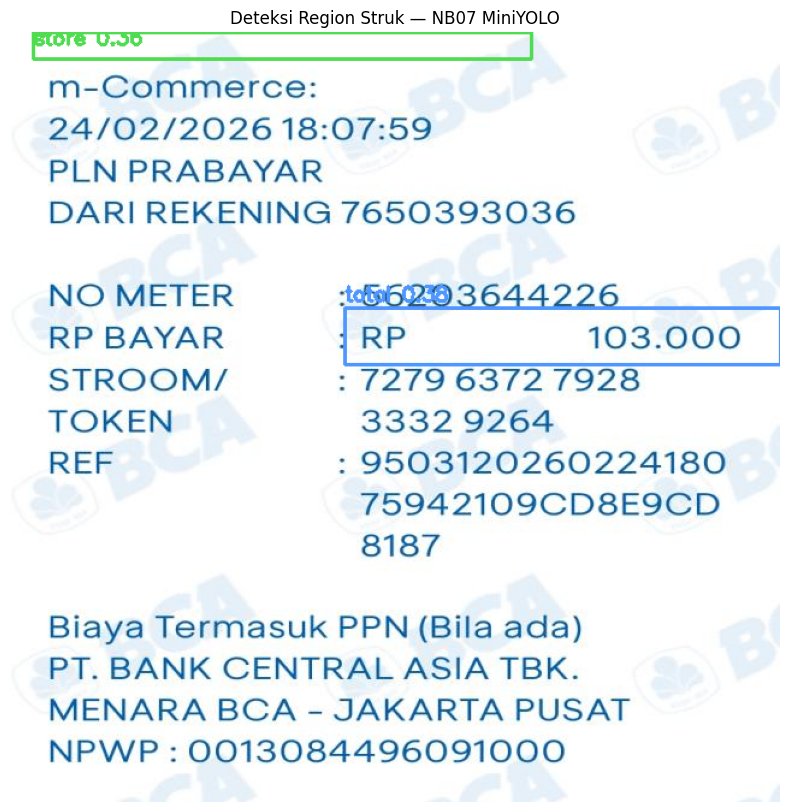


  [2/3] 📝 NB05 — OCR teks per region...
        store   : '44'  [CRNN]
        date    : ❌ tidak terdeteksi
        total   : 'RP 103 000'  [CRNN]

  [3/3] 🏷️  NB03 — Klasifikasi kategori...
        Teks input : '44 RP 103 000'
        Kategori   : Health  (conf=0.701)

  ───────────────────────────────────────────────────────
  📋 Hasil:
     Store    : 44
     Date     : None
     Total    : RP 103 000
     Kategori : Health  (conf=0.701)
     OCR      : crnn
     Regions  : 2 terdeteksi
  ───────────────────────────────────────────────────────

  🏷️  Kategori: Transport

  📷 Input : tol133_png.rf.4d9ef05dd73b105a64958ff41073488d.jpg

  [1/3] 🔍 NB07 — Deteksi region struk...
        Ditemukan 3 region:
        → total    (score=0.682)
        → date     (score=0.411)
        → store    (score=0.397)


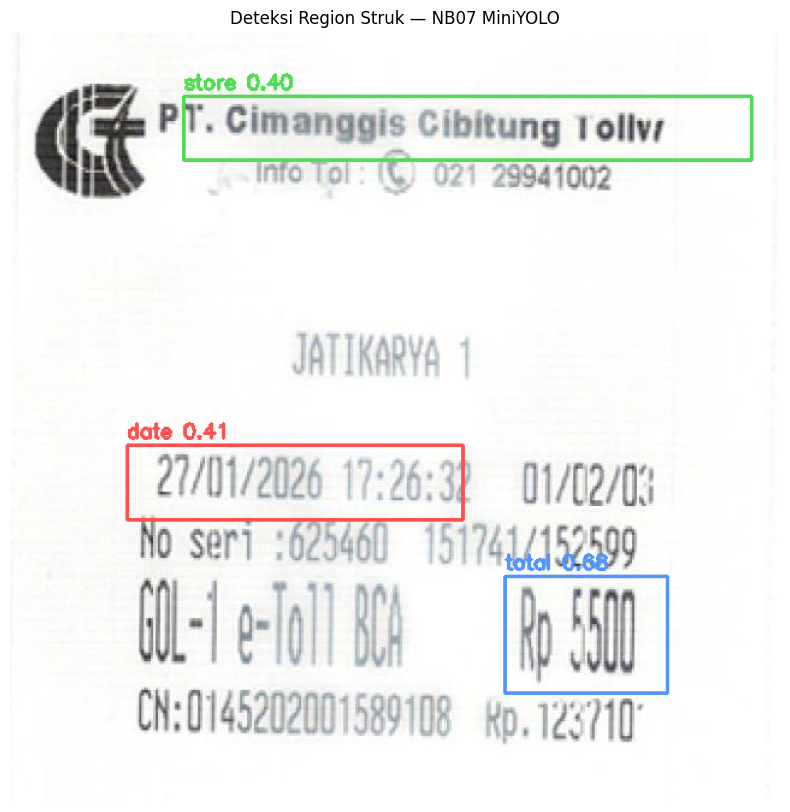


  [2/3] 📝 NB05 — OCR teks per region...
        store   : '. Cimanggis Cibitung 1olny'  [CRNN]
        date    : '27/01/2026 17:26:32'  [CRNN]
        total   : 'Hp 50'  [CRNN]

  [3/3] 🏷️  NB03 — Klasifikasi kategori...
        Teks input : '. Cimanggis Cibitung 1olny 27/01/2026 17:26:32 Hp 50'
        Kategori   : Transport  (conf=0.839)

  ───────────────────────────────────────────────────────
  📋 Hasil:
     Store    : . Cimanggis Cibitung 1olny
     Date     : 27/01/2026 17:26:32
     Total    : Hp 50
     Kategori : Transport  (conf=0.839)
     OCR      : crnn
     Regions  : 3 terdeteksi
  ───────────────────────────────────────────────────────


  Kategori     File                         Store            Date          Total         Pred Kat     Conf
  Beauty       guardian10_png.rf.3ef684fec  PT DFi Retail N  -             MANDIRI DEBT  Beauty       0.911
  F&B          bk6_png.rf.e34da0ca4e159ee4  e                2riir2or      Roii          Beauty       0.391
  Gas        

In [18]:
# ── Testing Single Image ──────────────────────────────────
import glob

# Ambil 1 gambar dari masing-masing kategori secara otomatis
BASE_DIR  = Path(os.getcwd()).parent
DATA_DIR  = BASE_DIR / "data"


# Kumpulkan 1 sample per kategori
test_samples = {}
for cat in CATEGORIES:
    pattern = str(DATA_DIR / cat / "test" / "images" / "*")
    files   = glob.glob(pattern)
    # filter hanya gambar
    files   = [f for f in files if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))]
    if files:
        test_samples[cat] = files[0]   # ambil 1 saja
    else:
        print(f"⚠️  Tidak ada gambar test di kategori: {cat}")

print(f"✅ Ditemukan {len(test_samples)} kategori dengan gambar test\n")

# ── Run pipeline 1 per kategori ──────────────────────────
all_results = {}
for cat, img_path in test_samples.items():
    print(f"\n{'='*60}")
    print(f"  🏷️  Kategori: {cat}")
    print(f"{'='*60}")

    result = spendly_pipeline(
        image_path  = img_path,
        conf_thresh = 0.35,
        iou_thresh  = 0.45,
        visualize   = True,
        save_vis    = False,
        verbose     = True,
    )
    all_results[cat] = result

# ── Summary tabel ─────────────────────────────────────────
print(f"\n\n{'='*95}")
print(f"  {'Kategori':<12} {'File':<28} {'Store':<16} {'Date':<13} {'Total':<13} {'Pred Kat':<12} {'Conf'}")
print(f"{'='*95}")

for cat, r in all_results.items():
    fname = Path(r["image_path"]).name[:27]
    store = (r["parsed"]["store"] or "-")[:15]
    date  = (r["parsed"]["date"]  or "-")[:12]
    total = (r["parsed"]["total"] or "-")[:12]
    pred  = r.get("kategori",   "unknown")[:11]
    conf  = r.get("confidence", 0.0)
    print(f"  {cat:<12} {fname:<28} {store:<16} {date:<13} {total:<13} {pred:<12} {conf:.3f}")

print(f"{'='*95}")

# ── Print JSON result kategori pertama sebagai contoh ─────
first_cat  = list(all_results.keys())[0]
first_result = all_results[first_cat]
result_json  = {k: v for k, v in first_result.items() if k != "crops"}

print(f"\n📦 Contoh JSON Output ({first_cat}):")
print(json.dumps(result_json, indent=2, ensure_ascii=False))

## 6. Batch Testing — Multiple Images per Kategori

Testing pipeline dengan beberapa gambar per kategori untuk mengukur konsistensi hasil. Setiap kategori diambil maksimal 3 gambar dari folder test, kemudian dijalankan pipeline penuh dan dirangkum dalam tabel agregat.

In [19]:
# ── Kumpulkan Sample Batch ────────────────────────────────────
MAX_PER_CAT = 3

batch_samples = {}
for cat in CATEGORIES:
    pattern = str(DATA_DIR / cat / "test" / "images" / "*")
    files   = glob.glob(pattern)
    files   = [f for f in files if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))]
    if files:
        batch_samples[cat] = files[:MAX_PER_CAT]
    else:
        print(f"⚠️  Tidak ada gambar test di kategori: {cat}")

total_images = sum(len(v) for v in batch_samples.values())
print(f"✅ Total gambar batch: {total_images} ({MAX_PER_CAT} per kategori)")

✅ Total gambar batch: 27 (3 per kategori)


In [20]:
# ── Run Pipeline Batch ────────────────────────────────────────
batch_results = []
for cat, img_paths in batch_samples.items():
    for img_path in img_paths:
        result = spendly_pipeline(
            image_path  = img_path,
            conf_thresh = 0.35,
            iou_thresh  = 0.45,
            visualize   = False,
            save_vis    = False,
            verbose     = False,
        )
        result["true_kategori"] = cat
        batch_results.append(result)

print(f"✅ Selesai: {len(batch_results)} gambar diproses")

✅ Selesai: 27 gambar diproses


In [21]:
# ── Summary Tabel Batch ───────────────────────────────────────
correct = sum(1 for r in batch_results if r.get("kategori") == r["true_kategori"])
total   = len(batch_results)

print(f"\n{'='*105}")
print(f"  {'True Kat':<12} {'Pred Kat':<12} {'Conf':<7} {'Store':<16} {'Date':<13} {'Total':<13} {'File'}")
print(f"{'='*105}")

for r in batch_results:
    true_cat = r["true_kategori"][:11]
    pred_cat = r.get("kategori", "unknown")[:11]
    conf     = r.get("confidence", 0.0)
    store    = (r["parsed"]["store"] or "-")[:15]
    date     = (r["parsed"]["date"]  or "-")[:12]
    total_   = (r["parsed"]["total"] or "-")[:12]
    fname    = Path(r["image_path"]).name[:20]
    match    = "✅" if pred_cat == true_cat else "❌"
    print(f"  {match} {true_cat:<11} {pred_cat:<12} {conf:.3f}  {store:<16} {date:<13} {total_:<13} {fname}")

print(f"{'='*105}")
print(f"\n  Akurasi Batch : {correct}/{total} ({correct/total*100:.1f}%)")
print(f"  OCR Method    : crnn")
print(f"  Detector      : miniyolo")


  True Kat     Pred Kat     Conf    Store            Date          Total         File
  ✅ Beauty      Beauty       0.911  PT DFi Retail N  -             MANDIRI DEBT  guardian10_png.rf.3e
  ❌ Beauty      F&B          0.573  Pr Dri Retai Ns  3035782 SEN   CCA QRIS T10  guardian1_png.rf.501
  ✅ Beauty      Beauty       0.703  GLUARD THE PARK  :45 18/04/20  -BI DEBTT 70  guardian6_png.rf.dea
  ❌ F&B         Beauty       0.391  e                2riir2or      Roii          bk6_png.rf.e34da0ca4
  ✅ F&B         F&B          0.310  Fere ceffee      Sunday A Jan  -             fore11_png.rf.eac728
  ✅ F&B         F&B          0.984  Fore Coffee      esday 3Jwnun  ToRnbuA R2j   fore17_png.rf.0f1f8b
  ✅ Gas         Gas          0.317  sppua5 50        -             eNgs eung pe  bensin-affan1_jpeg.r
  ✅ Gas         Gas          0.490  445321           -             Tolal Harja:  camscaner-bensin-yan
  ✅ Gas         Gas          0.801  N INTEN ID 1251  -             Vohiyla No H  shell3_png.rf.62

In [22]:
# ── Export Hasil Batch ke JSON ────────────────────────────────
output_path = BASE_DIR / "outputs" / "nb08_batch_results.json"
output_path.parent.mkdir(parents=True, exist_ok=True)

export_results = []
for r in batch_results:
    export_results.append({k: v for k, v in r.items() if k != "crops"})

with open(output_path, "w", encoding="utf-8") as f:
    json.dump(export_results, f, indent=2, ensure_ascii=False)

print(f"✅ Hasil batch disimpan ke: {output_path}")

✅ Hasil batch disimpan ke: c:\file akmal\Capstone - Ai Eng - Spendly_ Workspace\outputs\nb08_batch_results.json


## 7. Ringkasan & Checklist

In [23]:
# ── Ringkasan Final NB08 ─────────────────────────────────
print("=" * 65)
print("  NOTEBOOK 08 — RINGKASAN INTEGRASI END-TO-END")
print("=" * 65)

print("\n  Status Model:")
print(f"  {'✅' if nb07_ok else '⚠️ '} NB07  MiniYOLO Detector   — {NB07_MODEL_PATH}")
print(f"  {'✅' if nb05_ok else '⚠️ '} NB05  CRNN OCR            — {NB05_MODEL_PATH}")
print(f"  {'✅' if nb03_ok else '⚠️ '} NB03  Classifier          — {NB03_MODEL_PATH}")

print("\n  Fungsi yang Di-define:")
checklist = [
    "✅  preprocess_receipt()       — load + resize + normalize gambar",
    "✅  detect_receipt_regions()   — NB07 inference → dict{date,store,total}",
    "✅  decode_predictions_dual()  — merge dual-head 26×26 + 52×52",
    "✅  visualize_detections()     — overlay bounding box",
    "✅  preprocess_crop_for_ocr()  — CLAHE + denoise + resize crop",
    "✅  decode_ocr_prediction()    — CTC greedy decode",
    "✅  spendly_pipeline()         — pipeline utama end-to-end",
]
for item in checklist:
    print(f"  {item}")

print("\n  Output Format JSON:")
sample_output = {
    "image_path":      "test_images/sample_receipt.jpg",
    "parsed":          {"store": "INDOMARET", "date": "12/05/2025", "total": "Rp105.800"},
    "kategori":        "Groceries",
    "confidence":      0.92,
    "ocr_method":      "crnn",
    "detector_method": "miniyolo",
    "n_regions":       3,
    "timestamp":       "2025-05-12 10:30:00",
}
print(json.dumps(sample_output, indent=4, ensure_ascii=False))

print("\n  Known Issues / Catatan:")
notes = [
    "⚠️  NB03: custom_objects mungkin perlu disesuaikan setelah NB03 tersedia.",
    "⚠️  NB03: input preprocessing (Section 4) menggunakan crop store/total.",
    "    Sesuaikan resize target jika input NB03 bukan 224×224.",
    "⚠️  Jika NB05 gagal load → regex_fallback aktif otomatis.",
    "⚠️  conf_thresh default 0.25 — turunkan ke 0.20 jika banyak miss.",
    "ℹ️  NB08 hanya untuk testing — bukan deployment production.",
]
for note in notes:
    print(f"  {note}")

print("\n" + "=" * 65)
print("  ✅ Notebook 08 siap dijalankan!")
print("=" * 65)


  NOTEBOOK 08 — RINGKASAN INTEGRASI END-TO-END

  Status Model:
  ✅ NB07  MiniYOLO Detector   — ../models/receipt_detector_best.keras
  ✅ NB05  CRNN OCR            — ../models/ocr/ocr_fixed.keras
  ✅ NB03  Classifier          — ../models/classifier/classifier.keras

  Fungsi yang Di-define:
  ✅  preprocess_receipt()       — load + resize + normalize gambar
  ✅  detect_receipt_regions()   — NB07 inference → dict{date,store,total}
  ✅  decode_predictions_dual()  — merge dual-head 26×26 + 52×52
  ✅  visualize_detections()     — overlay bounding box
  ✅  preprocess_crop_for_ocr()  — CLAHE + denoise + resize crop
  ✅  decode_ocr_prediction()    — CTC greedy decode
  ✅  spendly_pipeline()         — pipeline utama end-to-end

  Output Format JSON:
{
    "image_path": "test_images/sample_receipt.jpg",
    "parsed": {
        "store": "INDOMARET",
        "date": "12/05/2025",
        "total": "Rp105.800"
    },
    "kategori": "Groceries",
    "confidence": 0.92,
    "ocr_method": "crnn",
    